### **Information Extraction**

In questa sezione del progetto verranno utilizzate tecniche di **NLP** per trasformare il testo non strutturato delle richieste in dati quantitativi e strutturati.

L'analisi si articolerà in diverse fasi per catturare sfumature diverse del linguaggio:
1.  **Information Extraction:** identificazione di entità specifiche (es. *Famiglia*, *Lavoro*, *Karma*) per capire il contenuto delle storie.
2.  **Analisi Grammaticale (POS Tagging):** studio dello stile di scrittura (uso di pronomi, verbi, aggettivi) per individuare pattern emotivi o narrativi.
3.  **Analisi Sintattica:** esame della struttura delle frasi per capire se i richiedenti si pongono come soggetti attivi o passivi.

In [1]:
%pip install spacy pandas
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import spacy
from spacy.pipeline import EntityRuler
from spacy import displacy
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

### **Named Entity Recognition (NER)**

Come primo passo, verranno eseguite operazioni di **Named Entity Recognition (NER)** utilizzando la libreria **spaCy**. Nello specifico:

**1. Inizializzazione**: si carica il modello linguistico inglese (`en_core_web_sm`).

**2. Definizione dei Pattern**: viene creata una lista di regole per identificare categorie specifiche di entità non standard, tra cui:
   - Famiglia e Relazioni: se vengono menzionati familiari o partner;
   - Lavoro e Studio: ruolo nella società, se in cerca di lavoro, etc...;
   - Finanza: stato finanziario degli utenti;
   - Salute ed Emozioni: stato d'animo degli utenti;
   - Eventi: compleanni o feste;
   - Reciprocità: promesse di "restituire il favore".

**3. EntityRuler**: si aggiunge questo componente alla pipeline posizionandolo prima del riconoscimento standard, per garantire che le regole personalizzate abbiano la priorità.


In [3]:
# Caricamento del modello base di spaCy
nlp = spacy.load("en_core_web_sm")

# Definizione dei Pattern di rilevamento
# "LEMMA": catturare variazioni (es. "kid" cattura "kids")
# "LOWER": match esatti in minuscolo
# "IN": match esatti
# "REGEX": match con espressioni regolari
patterns = [
    # ---------------------------------------------------------
    # 1. FAMILY & RELATIONSHIPS
    # ---------------------------------------------------------
    {"label": "FAMILY", "pattern": [{"LEMMA": {"IN": ["kid", "child", "son", "daughter", "baby", "family", "parent", "mom", "mother", "mum", "dad", "father"]}}]},
    # Partner e Coinquilini
    {"label": "RELATIONSHIP", "pattern": [{"LEMMA": {"IN": ["girlfriend", "boyfriend", "gf", "bf", "wife", "husband", "partner", "fiance", "fiancee"]}}]},
    {"label": "RELATIONSHIP", "pattern": [{"LEMMA": {"IN": ["friend", "roommate", "roomie", "buddy", "pal"]}}]},

    # ---------------------------------------------------------
    # 2. JOB & EDUCATION
    # ---------------------------------------------------------
    {"label": "STUDENT", "pattern": [{"LEMMA": {"IN": ["student", "college", "university", "uni", "school", "class", "exam", "study", "semester", "final"]}}]},
    {"label": "JOB_ISSUE", "pattern": [{"LEMMA": {"IN": ["unemployed", "jobless", "fired", "laid", "interview", "paycheck", "payday"]}}]},
    # "Between jobs", "Lost my job"
    {"label": "JOB_ISSUE", "pattern": [{"LOWER": "lost"}, {"LOWER": "my"}, {"LEMMA": "job"}]},
    {"label": "JOB_ISSUE", "pattern": [{"LOWER": "between"}, {"LEMMA": "job"}]},

    # ---------------------------------------------------------
    # 3. MONEY & FINANCIAL
    # ---------------------------------------------------------
    {"label": "FINANCIAL", "pattern": [{"LEMMA": {"IN": ["broke", "poor", "bill", "rent", "debt", "penniless", "budget"]}}]},
    {"label": "FINANCIAL", "pattern": [{"LOWER": "no"}, {"LEMMA": "money"}]},
    {"label": "FINANCIAL", "pattern": [{"LOWER": "no"}, {"LEMMA": "cash"}]},
    {"label": "FINANCIAL", "pattern": [{"LOWER": "until"}, {"LOWER": "friday"}]},
    {"label": "FINANCIAL", "pattern": [{"LOWER": "empty"}, {"LEMMA": "fridge"}]},
    {"label": "FINANCIAL", "pattern": [{"LEMMA": "steal"}]},
    {"label": "FINANCIAL", "pattern": [{"LEMMA": "wallet"}]},

    # ---------------------------------------------------------
    # 4. EMOTION & HEALTH
    # ---------------------------------------------------------
    # Salute
    {"label": "CONDITION", "pattern": [{"LEMMA": {"IN": ["sick", "flu", "fever", "ill", "hospital", "injury", "broken", "pain", "starving", "hungry"]}}]},
    {"label": "CONDITION", "pattern": [{"LOWER": "under"}, {"LOWER": "the"}, {"LOWER": "weather"}]},
    # Stato Mentale/Emotivo
    {"label": "CONDITION", "pattern": [{"LEMMA": {"IN": ["sad", "depressed", "bummed", "stressed", "tired", "exhausted", "upset", "crave", "craving"]}}]},
    # Hangover
    {"label": "CONDITION", "pattern": [{"LEMMA": {"IN": ["hangover", "hungover", "drunk", "wasted", "high", "munchies"]}}]},

    # ---------------------------------------------------------
    # 5. CELEBRATION & EVENTS
    # ---------------------------------------------------------
    {"label": "CELEBRATION", "pattern": [{"LEMMA": {"IN": ["birthday", "bday", "anniversary", "party", "celebrate", "celebration", "wedding"]}}]},
    {"label": "CELEBRATION", "pattern": [{"LOWER": "cheer"}, {"LOWER": "me"}, {"LOWER": "up"}]},

    # ---------------------------------------------------------
    # 6. RECIPROCITY & OFFERS
    # ---------------------------------------------------------
    {"label": "RECIPROCITY", "pattern": [{"LOWER": "pay"}, {"LOWER": "it"}, {"LOWER": "forward"}]},
    {"label": "RECIPROCITY", "pattern": [{"LOWER": "return"}, {"LOWER": "the"}, {"LOWER": "favor"}]},
    {"label": "RECIPROCITY", "pattern": [{"LEMMA": "draw"}]},
    {"label": "RECIPROCITY", "pattern": [{"LEMMA": "pic"}]},
]

# Entity Ruler
if "entity_ruler" not in nlp.pipe_names:
    ruler = nlp.add_pipe("entity_ruler", before="ner")
    ruler.add_patterns(patterns)
    
# Caricamento del DataFrame
df = pd.read_json('data/train/train.json')
texts = df['request_text_edit_aware'].head(10).tolist()
docs = list(nlp.pipe(texts))

# Debug testuale
for doc in docs:
    if doc.ents: 
        print(f"Testo: {doc.text[:50]}...")
        print(f"Entità: {[(ent.text, ent.label_) for ent in doc.ents]}")
        print("-" * 20)

# Visualizzazione Grafica
# 1. Etichette
TARGET_LABELS = ["FAMILY", "STUDENT", "JOB_ISSUE", "FINANCIAL", 
                 "CONDITION", "CELEBRATION", "RECIPROCITY"]

# 2. Filtraggio dei documenti
docs_to_render = []

for doc in docs:
    # Si controlla se nel documento c'è almeno un'entità che appartiene alle categorie
    has_target_entity = any(ent.label_ in TARGET_LABELS for ent in doc.ents)
    
    if has_target_entity:
        docs_to_render.append(doc)

# 3. Statistiche rapide
print(f"Totale documenti analizzati: {len(docs)}")
print(f"Documenti con entità trovate: {len(docs_to_render)}")
print("-" * 30)

# 4. Visualizzazione Grafica
colors = {"FAMILY": "#F67DE3", "STUDENT": "#7DF6D9", "JOB_ISSUE": "#FF5733", 
          "FINANCIAL": "#FFC300", "CONDITION": "#41B8B8", 
          "CELEBRATION": "#CE2B2B", "RECIPROCITY": "#59CF7C"}
options = {"ents": TARGET_LABELS, "colors": colors}

if docs_to_render:
    displacy.render(docs_to_render, style="ent", jupyter=True, options=options)
else:
    print("Nessuna delle entità specificate è stata trovata nei testi selezionati.")

Testo: Hi I am in need of food for my 4 children we are a...
Entità: [('4', 'CARDINAL'), ('children', 'FAMILY'), ('family', 'FAMILY'), ('family', 'FAMILY'), ('another night', 'TIME')]
--------------------
Testo: I spent the last money I had on gas today. Im brok...
Entità: [('today', 'DATE'), ('broke', 'FINANCIAL'), ('next Thursday', 'DATE')]
--------------------
Testo: My girlfriend decided it would be a good idea to g...
Entità: [('girlfriend', 'RELATIONSHIP'), ('Perth', 'ORG'), ('Dundee', 'GPE')]
--------------------
Testo: It's cold, I'n hungry, and to be completely honest...
Entità: [('hungry', 'CONDITION'), ('broke', 'FINANCIAL'), ('mum', 'FAMILY')]
--------------------
Testo: hey guys:
 I love this sub. I think it's great. (E...
Entità: [('Anywho', 'PERSON'), ('friend', 'RELATIONSHIP'), ('an hour', 'TIME'), ('friend', 'RELATIONSHIP')]
--------------------
Testo: Feeling under the weather so I called out off work...
Entità: [('under the weather', 'CONDITION'), ('today', 'DATE'), 

#### **Analisi iniziale**

A primo impatto, i risultati mostrano una grande capacità del modello di "capire" il **contesto umano e sociale** delle richieste, andando oltre la semplice identificazione di nomi e luoghi.

- **Cattura delle motivazioni reali**: il modello identifica chiaramente i driver primari della richiesta: `FINANCIAL` (broke, rent, poor) e `CONDITION` (hungry, under the weather). Non sta più solo leggendo il testo, sta iniziando a capire il perché qualcuno chiede aiuto.

- **Mappatura sociale accurata**: si vede emergere una rete sociale più complessa con `RELATIONSHIP` (girlfriend, roommates, friends). Questo è cruciale perché spesso le richieste di pizza sono per gruppi o situazioni sociali, non solo per nuclei familiari tradizionali.

- **Reciprocità**: l'identificazione del tag `RECIPROCITY` è un dettaglio fondamentale. Rivela che l'utente sta cercando di offrire qualcosa in cambio, una dinamica psicologica molto forte in questa community (il "Karma").

- **Poco rumore**: nonostante ci siano ancora entità standard (come `DATE` o `GPE`), le entità personalizzate dominano la scena visiva, raccontando una storia coerente.

---

#### **Analisi statistica**

Il prossimo passo è quello di visualizare l'**impatto** che le diverse categorie narrative hanno sulla probabilità di successo della richiesta.
Quindi, come prima cosa viene eseguita una trasformazione delle informazioni estratte in dati numerici strutturati, utilizzabili per un'analisi statistica.

In [4]:
# Estrazione di tutti i documenti
docs = list(nlp.pipe(df['request_text_edit_aware']))

# Funzione per estrarre le categorie
def extract_features(docs):
    data = []
    for doc in docs:
        row = {
            # Contatori
            "has_family": 0,
            "has_student": 0,
            "has_job_issue": 0,
            "has_financial": 0,
            "has_condition": 0,
            "has_celebration": 0,
            "has_reciprocity": 0,
            
            # Quante entità ci sono in totale
            "entity_count": 0,
            
            # Salvataggio delle parole esatte
            "extracted_keywords": []
        }
        
        relevant_ents = [ent for ent in doc.ents if ent.label_ in
                         ["FAMILY", "STUDENT", "JOB_ISSUE", "FINANCIAL",
                          "CONDITION", "CELEBRATION", "RECIPROCITY"]]
        row["entity_count"] = len(relevant_ents)
        
        for ent in relevant_ents:
            row["extracted_keywords"].append(ent.text)
            if ent.label_ == "FAMILY":
                row["has_family"] = 1
            if ent.label_ == "STUDENT":
                row["has_student"] = 1
            if ent.label_ == "JOB_ISSUE":
                row["has_job_issue"] = 1
            if ent.label_ == "FINANCIAL":
                row["has_financial"] = 1
            if ent.label_ == "CONDITION":
                row["has_condition"] = 1
            if ent.label_ == "CELEBRATION":
                row["has_celebration"] = 1
            if ent.label_ == "RECIPROCITY":
                row["has_reciprocity"] = 1
        
        data.append(row)
    return pd.DataFrame(data)

# Creazione del DataFrame ed unione con l'originale
df_features = extract_features(docs)
df_final = pd.concat([df[['requester_received_pizza']], df_features], axis=1)

print("Estrazione completata!")
display(df_final.head())

Estrazione completata!


,requester_received_pizza,has_family,has_student,has_job_issue,has_financial,has_condition,has_celebration,has_reciprocity,entity_count,extracted_keywords
0,False,1,0,0,0,0,0,0,3,"[children, family, family]"
1,False,0,0,0,1,0,0,0,1,[broke]
2,False,0,0,0,0,0,0,0,0,[]
3,False,1,0,0,1,1,0,0,3,"[hungry, broke, mum]"
4,False,0,0,0,0,0,0,0,0,[]


#### **Preparazione dei dati**

Dopo aver estratto le informazioni primarie, viene eseguita una **media generale** di successo (`baseline_success`) sull'intero dataset (quindi la probabilità a priori di ricevere una pizza senza considerare il contenuto).
Inoltre, vengono calcolate le **medie condizionate** per ogni specifica categoria.

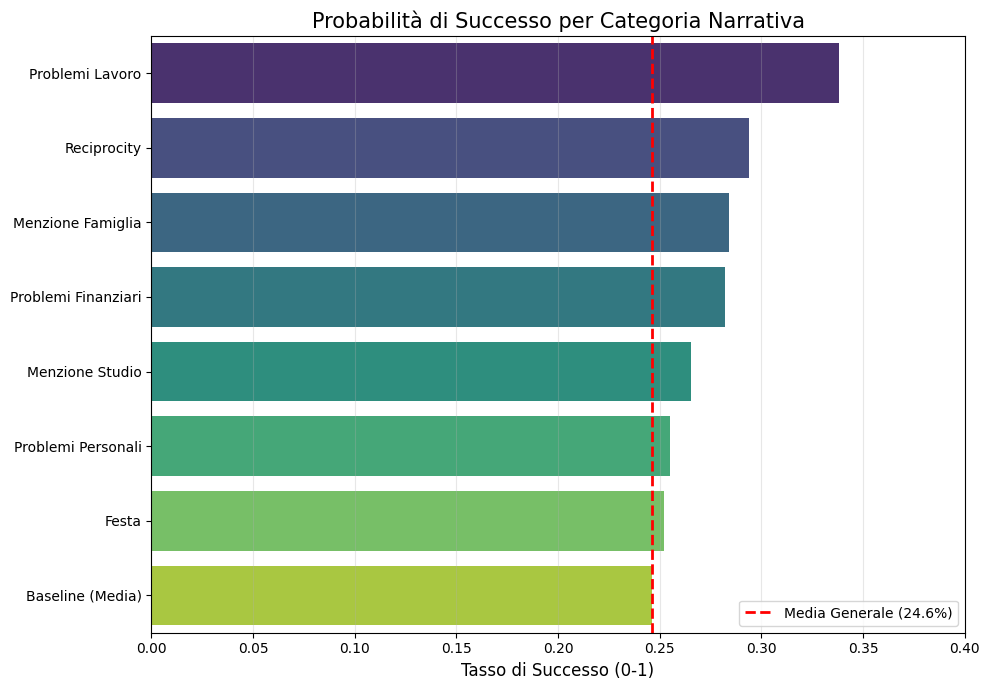

--- Tassi di Successo ---
Baseline (Media): 24.60% (Differenza: +0.00%)
Menzione Famiglia: 28.41% (Differenza: +3.81%)
Menzione Studio: 26.53% (Differenza: +1.93%)
Problemi Lavoro: 33.80% (Differenza: +9.19%)
Problemi Finanziari: 28.22% (Differenza: +3.61%)
Problemi Personali: 25.49% (Differenza: +0.89%)
Festa: 25.20% (Differenza: +0.59%)
Reciprocity: 29.39% (Differenza: +4.79%)


In [5]:
# Calcolo delle medie
baseline_success = df_final['requester_received_pizza'].mean()
results = {
    'Baseline (Media)': baseline_success,
    'Menzione Famiglia': df_final[df_final['has_family'] == 1]['requester_received_pizza'].mean(),
    'Menzione Studio': df_final[df_final['has_student'] == 1]['requester_received_pizza'].mean(),
    'Problemi Lavoro': df_final[df_final['has_job_issue'] == 1]['requester_received_pizza'].mean(),
    'Problemi Finanziari': df_final[df_final['has_financial'] == 1]['requester_received_pizza'].mean(),
    'Problemi Personali': df_final[df_final['has_condition'] == 1]['requester_received_pizza'].mean(),
    'Festa': df_final[df_final['has_celebration'] == 1]['requester_received_pizza'].mean(),
    'Reciprocity': df_final[df_final['has_reciprocity'] == 1]['requester_received_pizza'].mean()
}

# Creazione DataFrame per il grafico
df_viz = pd.DataFrame(list(results.items()), columns=['Categoria', 'Success Rate'])
df_viz = df_viz.sort_values('Success Rate', ascending=False)

# --- GRAFICO ORIZZONTALE ---
plt.figure(figsize=(10, 7))

sns.barplot(x='Success Rate', y='Categoria', data=df_viz, palette="viridis")

# Linea verticale della media
plt.axvline(x=baseline_success, color='r', linestyle='--', linewidth=2, label=f'Media Generale ({baseline_success:.1%})')

plt.title('Probabilità di Successo per Categoria Narrativa', fontsize=15)
plt.xlabel('Tasso di Successo (0-1)', fontsize=12)
plt.ylabel('')
plt.xlim(0, 0.4)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Percentuali risultati
print("--- Tassi di Successo ---")

for cat, rate in results.items():
    diff = (rate - baseline_success) * 100
    print(f"{cat}: {rate:.2%} (Differenza: {diff:+.2f}%)")

#### **Analisi della probabilità di successo**

Osservando il grafico e i numeri, si possono trarre delle conclusioni sociologiche:

**1. Problemi di lavoro (+9.35)**: è il driver più forte, la disoccupazione è nettamente la categoria vincente. Quindi, è evidente che la community **empatizza molto di più** con chi ha perso il lavoro o è stato licenziato rispetto a qualsiasi altra categoria, poiché è un problema percepito come **involontario** e urgente.

**2. Reciprocity/Karma (+4.79%)**: promettere di restituire il favore o offrire qualcosa in cambio **è quasi potente quanto avere una famiglia da sfamare**. La community vuole sentire che non sei solo un "parassita", ma un membro attivo che restituirà.

**3. La famiglia (+3.81%)**: menzionare figli o famiglia aiuta, ma meno rispetto alla perdita del lavoro.

**4. Problemi finanziari (+3.61%)**: dire "sono al verde" funziona, ma meno di "ho perso il lavoro" (che implica una causa esterna sfortunata).

**5. Studenti (+1.93%) & Problemi Personali (+0.89%)**: dire "sono triste" o "ho l'hangover" (Condition) o "sono uno studente" sposta l'ago della bilancia pochissimo. È troppo comune.

**6. Festa (+0.59%)**: chiedere pizza per un compleanno è sostanzialmente inutile ai fini statistici.

---

### **Part-of-Speech (POS) Tagging**

In questa fase si esplorerà se chi riceve una pizza utilizza un linguaggio più **emotivo** (tanti aggettivi) o più **fattuale** (tanti sostantivi). Anche l'uso di **verbi al passato** (raccontano storie) o al presente/futuro è importante. Quindi, si conterà la percentuale di **aggettivi, verbi, nomi, pronomi e avverbi** per ogni richiesta.

Estrazione caratteristiche grammaticali in corso...
          No Pizza (Fallimento)  Sì Pizza (Successo)
pos_ADJ                0.051109             0.051755
pos_VERB               0.117089             0.114525
pos_NOUN               0.153591             0.152448
pos_PRON               0.124761             0.126874
pos_ADV                0.057900             0.059916


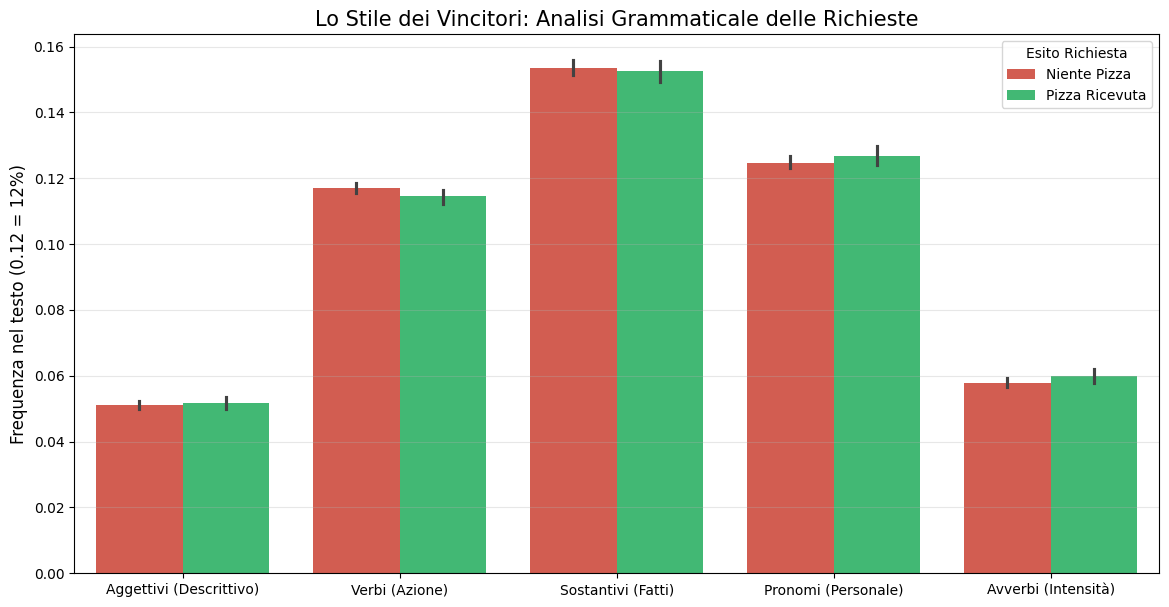

In [6]:
# Calcolo dei POS Tag e Distribuzione grammaticale
def analyze_grammar_style(docs):
    data = []
    
    # Definizione degli ID
    target_pos = {
        "ADJ": spacy.symbols.ADJ,
        "VERB": spacy.symbols.VERB,
        "NOUN": spacy.symbols.NOUN,
        "PRON": spacy.symbols.PRON,
        "ADV": spacy.symbols.ADV
    }
    
    for doc in docs:
        # Quante volte appare ogni POS tag nel documento
        counts = doc.count_by(spacy.attrs.POS)
        total_words = len(doc)
        
        if total_words == 0:
            total_words = 1
            
        row = {}
        
        # Calcolo delle percentuali
        for label, pos_id in target_pos.items():
            row[f"pos_{label}"] = counts.get(pos_id, 0) / total_words
            
        data.append(row)
        
    return pd.DataFrame(data)

print("Estrazione caratteristiche grammaticali in corso...")
df_grammar = analyze_grammar_style(docs)

# Unione con il target (Successo Sì/No)
df_grammar['received_pizza'] = df['requester_received_pizza'].values

# Calcolo delle medie per i due gruppi (Pizza ricevuta vs Non ricevuta)
summary = df_grammar.groupby('received_pizza').mean().transpose()
summary.columns = ['No Pizza (Fallimento)', 'Sì Pizza (Successo)']

print(summary)

df_viz = df_grammar.copy()
rename_map = {
    'pos_ADJ_rate': 'Aggettivi (Descrittivo)',
    'pos_VERB_rate': 'Verbi (Azione)',
    'pos_NOUN_rate': 'Sostantivi (Fatti)',
    'pos_PRON_rate': 'Pronomi (Personale)',
    'pos_ADV_rate': 'Avverbi (Intensità)'
}

rename_map_fix = {k.replace('_rate', ''): v for k, v in rename_map.items()} 
df_viz.rename(columns=rename_map_fix, inplace=True)

# Etichette per il grasfico
df_viz['received_pizza'] = df_viz['received_pizza'].map({True: 'Pizza Ricevuta', False: 'Niente Pizza'})

# "Melt" del dataframe per il grafico
df_melted = df_viz.melt(
    id_vars="received_pizza", 
    value_vars=list(rename_map.values()), 
    var_name="Tipo di Parola", 
    value_name="Frequenza"
)

# Grafico
plt.figure(figsize=(14, 7))
sns.barplot(
    x="Tipo di Parola", 
    y="Frequenza", 
    hue="received_pizza", 
    data=df_melted, 
    palette={'Niente Pizza': '#E74C3C', 'Pizza Ricevuta': '#2ECC71'}
)

plt.title("Lo Stile dei Vincitori: Analisi Grammaticale delle Richieste", fontsize=15)
plt.ylabel("Frequenza nel testo (0.12 = 12%)", fontsize=12)
plt.xlabel("")
plt.legend(title="Esito Richiesta")
plt.grid(axis='y', alpha=0.3)
plt.show()

#### **Analisi del POS Tagging**

Osservando i grafici e i numeri, si può dire che:

**1. I Pronomi sono la chiave**: è l'unica categoria dove i vincitori sono superiori. Questo conferma che scrivere in prima persona o rivolgersi direttamente agli altri crea connessione ed empatia.

**2. I verbi sono per i perdenti**: chi non riceve la pizza usa più verbi. Forse raccontano storie troppo lunghe e complicate piene di azioni ("I went there, then I did this, then this happened") che annoiano il lettore.

**3. Sostantivi**: anche qui, chi perde ne usa di più. Conferma la teoria che uno stile troppo fattuale/oggettivo (elenco di problemi o oggetti) è meno efficace di uno stile personale ed emotivo.

---

### **Syntactic Parsing (Analisi delle Dipendenze)**

L'obiettivo è **capire chi fa cosa**. Il NER dice che c'è una persona e un lavoro, mentre il **Syntactic Parsing** può dire se la persona ha perso il lavoro (attivo), o se il lavoro è stato perso (passivo). Quindi, verrà analizzata la **Agency**, ovvero la capacità di agire. Questo mostrerà se i vincitori sono soggetti attivi o passivi.

In [7]:
# Funzione per l'analisi sintattica
def analyze_syntax(docs):
    data = []
    
    for doc in docs:
        counts = {
            "nsubj": 0,
            "nsubjpass": 0,
            "dobj": 0,
            "root": 0
        }
        
        for token in doc:
            if token.dep_ in counts:
                counts[token.dep_] += 1
                
        # Normalizzazione lunghezza
        total = len(doc) if len(doc) > 0 else 1
        row = {k: v / total for k, v in counts.items()}
        data.append(row)
        
    return pd.DataFrame(data)

print("Esecuzione Syntactic Parsing...")
df_syntax = analyze_syntax(docs)
df_syntax['received_pizza'] = df['requester_received_pizza'].values

# Visualizzazione delle differenze
print(df_syntax.groupby('received_pizza').mean())

Esecuzione Syntactic Parsing...
                   nsubj  nsubjpass     dobj  root
received_pizza                                    
False           0.086313   0.004982  0.05761   0.0
True            0.087291   0.005816  0.05652   0.0


#### **Analisi del Syntactic Parsing**

Osservando la tabella del parsing si può capire che **chi riceve la pizza usa più spesso costruzioni passive**. Invece di dire "I lost my job" (Attivo), si tende a dire "I was fired" o "I was robbed" (Passivo).
Questo suggerisce che p**resentarsi come vittima** di eventi esterni (sfortuna involontaria) genera più empatia rispetto a presentarsi come agente attivo della propria situazione. La passività grammaticale segnala che "il mondo ti è crollato addosso", non che tu hai fatto crollare qualcosa.

Inoltre, i valori per i soggetti attivi (`nsubj`) e gli oggetti diretti (`dobj`) sono quasi identici tra i due gruppi.
Questo descrive come i vincitori non scrivono frasi più complesse in generale:**la struttura di base è la stessa**. La differenza sta proprio nella specifica scelta di subire l'azione (passivo) quando si raccontano le sventure.

---

### **Key Phrases Extraction (Frasi Chiave)**

L'obiettivo qui è **estrarre i concetti chiave**, non solo parole singole, con una funzione di **spaCy** chiamata `noun_chunks`, che permette di estrarre automaticamente questi gruppi nominali. Ad esempio, invece di vedere "account" e "bank" si vede "empty bank account".

In [8]:


def get_top_phrases(docs, target_labels, received_status):
    # Raccogliamo tutte le noun_chunks (es: "my lost job", "a hot pizza")
    phrases = []
    
    # Iteriamo simultaneamente su docs e labels
    for doc, label in zip(docs, target_labels):
        if label == received_status:
            for chunk in doc.noun_chunks:
                # Pulizia: ignoriamo pronomi ('I', 'me', 'it') per trovare concetti reali
                if chunk.root.pos_ != "PRON": 
                    phrases.append(chunk.text.lower())
    
    return Counter(phrases).most_common(15)

# Eseguiamo
target_labels = df['requester_received_pizza'].values

print("--- Top 15 Frasi Chiave: Chi HA RICEVUTO la pizza ---")
print(get_top_phrases(docs, target_labels, True))

print("\n--- Top 15 Frasi Chiave: Chi NON HA RICEVUTO la pizza ---")
print(get_top_phrases(docs, target_labels, False))

--- Top 15 Frasi Chiave: Chi HA RICEVUTO la pizza ---
[('a pizza', 347), ('pizza', 207), ('thanks', 195), ('food', 137), ('work', 127), ('money', 105), ('ramen', 65), ('some pizza', 62), ('a job', 61), ('help', 56), ('my job', 51), ('dinner', 49), ('rent', 49), ('things', 48), ('friday', 48)]

--- Top 15 Frasi Chiave: Chi NON HA RICEVUTO la pizza ---
[('a pizza', 944), ('pizza', 523), ('thanks', 465), ('food', 314), ('money', 259), ('work', 257), ('some pizza', 246), ('a job', 141), ('dinner', 138), ('ramen', 138), ('friday', 120), ('no money', 118), ('the favor', 117), ('things', 116), ('my job', 113)]


#### **Analisi Estrazione Frasi Chiave**

L'analisi delle Key Phrases offre una visione molto interessante sulla **specificità del linguaggio** usato dai due gruppi. Sebbene molte parole siano simili (ovviamente tutti parlano di "pizza", "food", "work"), le differenze nella "coda" della lista sono rivelatrici:

- **Vincitori**: nella top 15 compare "rent" (affitto), che è un problema specifico, tangibile e urgente. Compare anche "help", una richiesta diretta e onesta.

- **Perdenti**: compare "no money". Questo è generico: dire "non ho soldi" è meno efficace di dire "devo pagare l'affitto". Compare anche "the favor" (probabile "return the favor"), che a volte suona come una frase fatta se non supportata da una storia forte.

---

### **Relation Extraction (Estrazione delle Relazioni)**

L'obiettivo è **collegare i punti**, ovvero si vuole trovare un pattern del tipo **Subject-Verb-Object Triples** `(SOGGETTO) -> [AZIONE] -> (OGGETTO)`. Ad esempio: `I -> lost -> job`, `I -> need -> pizza`, etc.

Il codice cerca verbi specifici e stampa chi è il soggetto e chi è l'oggetto.

In [9]:
def extract_relations(docs, target_verbs=["lost", "need", "want", "craving", "share"]):
    print(f"--- Estrazione Relazioni per i verbi: {target_verbs} ---")
    
    relations_found = 0
    
    for i, doc in enumerate(docs):
        for token in doc:
            # Se il token è un verbo che ci interessa
            if token.lemma_ in target_verbs:
                subject = "Unknown"
                obj = "Unknown"
                
                # Cerchiamo i figli del verbo nell'albero sintattico
                for child in token.children:
                    if child.dep_ in ["nsubj", "nsubjpass"]: # Trova il soggetto
                        subject = child.text
                    if child.dep_ in ["dobj", "pobj"]: # Trova l'oggetto
                        obj = child.text
                
                # Se troviamo una relazione completa, stampiamola
                if subject != "Unknown" and obj != "Unknown":
                    print(f"Doc {i}: ({subject}) --[{token.lemma_.upper()}]--> ({obj})")
                    relations_found += 1
                    
                    if relations_found >= 15: # Ci fermiamo dopo 15 esempi per non intasare
                        return

extract_relations(docs)

--- Estrazione Relazioni per i verbi: ['lost', 'need', 'want', 'craving', 'share'] ---
Doc 7: (I) --[WANT]--> (joy)
Doc 31: (we) --[NEED]--> (energy)
Doc 38: (I) --[SHARE]--> (stamps)
Doc 38: (that) --[NEED]--> (much)
Doc 55: (I) --[NEED]--> (room)
Doc 89: (He) --[NEED]--> (care)
Doc 89: (he) --[NEED]--> (tests)
Doc 89: (he) --[NEED]--> (monitoring)
Doc 93: (I) --[NEED]--> (form)
Doc 93: (you) --[NEED]--> (it)
Doc 99: (i) --[NEED]--> (food)
Doc 104: (I) --[NEED]--> (help)
Doc 130: (I) --[NEED]--> (it)
Doc 140: (story) --[WANT]--> (pizza)
Doc 144: (you) --[WANT]--> (whatever)


#### **Analisi Estrazione Relazioni**

L'analisi di Relation Extraction (Estrazione delle Relazioni) offre una **profondità di comprensione** che le semplici parole chiave o il conteggio delle entità non possono dare. Mentre il NER ci dice chi o cosa è presente nel testo, l'estrazione delle relazioni mostra come questi elementi interagiscono.
Gli esempi estratti descrivono come i bisogni **non sono solo cibo**: `I --> want --> joy`, `He --> need -> care`. Quindi, l'analisi mostra che il "bisogno" di pizza è spesso una metafora o un mezzo per soddisfare bisogni più profondi.

Inoltre, il sostantivo `He` permette di capire **chi** ha effettivamente bisogno, distinguendo le richieste per sé da quelle per altri (che spesso hanno più successo per via dell'empatia). Qui emerge una narrazione medica o di cura verso una **terza persona** (un figlio, un partner). Si capisce che il soggetto della sofferenza non è chi scrive ("I"), ma un "Lui", il che crea una storia molto più potente.

Si può anche distinguere tra richieste dirette e vaghe, che è un fattore chiave per la fiducia. Le richieste **vaghe tendono a performare peggio** perché non forniscono un'immagine chiara al donatore.